# Polynomial chaos expansions


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import archimedes as arc


In [2]:
mu = 3.986e14  # Gravitational constant [m^3/s^2]
r_p = 6.678e6  # Parking-orbit radius [m]
r_a0 = 4.2164e7  # Initial apogee radius [m]

@arc.compile(buffered=True)
def propagate_burn(dr_a, dnu, dv_mag, dv_dir):
    # Transfer orbit
    r_a = r_a0 + dr_a  # Actual apogee radius w/ dispersion [m]
    a_t = (r_p + r_a) / 2  # Semi-major axis [m]
    e_t = (r_a - r_p) / (r_a + r_p)  # Eccentricity
    h = np.sqrt(mu * a_t * (1 - e_t**2))  # Angular momentum [m^2/s]

    nu = np.radians(180) + dnu  # True anomaly at burn [rad]

    # Local radius and radial/tangential velocity at burn
    r = a_t * (1 - e_t**2) / (1 + e_t * np.cos(nu))  # Radius [m]
    v_t = (mu / h) * (1 + e_t * np.cos(nu))  # Tangential velocity [m/s]
    v_r = (mu / h) * e_t * np.sin(nu)  # Radial velocity [m/s]

    # Delta-v for circularization burn
    v_circ = np.sqrt(mu / r_a0)  # Circular velocity at apogee [m/s]
    v_t_nom = (mu / h) * (1 - e_t)  # Nominal tangential velocity at burn [m/s]
    dv_nom = v_circ - v_t_nom  # Nominal delta-v [m/s]

    # Add dispersion to delta-v magnitude and direction
    dv_mag = dv_nom + dv_mag  # Actual delta-v magnitude [m/s]
    dv_r = dv_mag * np.sin(dv_dir)  # Radial component of delta-v [m/s]
    dv_t = dv_mag * np.cos(dv_dir)  # Tangential component of delta-v [m/s]

    # Final orbit after burn
    v_r_f = v_r + dv_r  # Final radial velocity [m/s]
    v_t_f = v_t + dv_t  # Final tangential velocity [m/s]
    E_f = 0.5 * v_r_f**2 + 0.5 * v_t_f**2 - mu / r  # Specific energy [m^2/s^2]
    a_f = -mu / (2 * E_f)  # Semi-major axis [m]
    h_f = r * v_t_f  # Angular momentum [m^2/s]
    e_f = np.sqrt(1 - np.fmin(1, h_f**2 / (mu * a_f)))  # Eccentricity
    r_a_f = a_f * (1 + e_f)  # Final apogee radius [m]
    r_p_f = a_f * (1 - e_f)  # Final perigee radius [m]

    return e_f, r_a_f, r_p_f


# Monte Carlo
sigma_dr_a = 100e3  # Apogee radius dispersion [m]
sigma_dnu = np.radians(0.1)  # True anomaly dispersion [rad]
sigma_dv_mag = 5.0  # Delta-v magnitude dispersion [m/s]
sigma_dv_dir = np.radians(0.3)  # Delta-v direction dispersion [rad]

n_samples = 100000
e_samples = np.zeros(n_samples)
r_a_samples = np.zeros(n_samples)
r_p_samples = np.zeros(n_samples)
dr_a_samples = np.random.normal(0, sigma_dr_a, n_samples)
dnu_samples = np.random.normal(0, sigma_dnu, n_samples)
dv_mag_samples = np.random.normal(0, sigma_dv_mag, n_samples)
dv_dir_samples = np.random.normal(0, sigma_dv_dir, n_samples)
for i in range(n_samples):
    dr_a = dr_a_samples[i]
    dnu = 0
    dv_mag = 0
    dv_dir = 0

    e_samples[i], r_a_samples[i], r_p_samples[i] = propagate_burn(dr_a, dnu, dv_mag, dv_dir)


In [3]:
r_a_err = r_a_samples - r_a0
r_p_err = r_p_samples - r_a0
max_is_apogee = abs(r_a_err) > abs(r_p_err)
r_err = np.where(max_is_apogee, r_a_err, r_p_err)

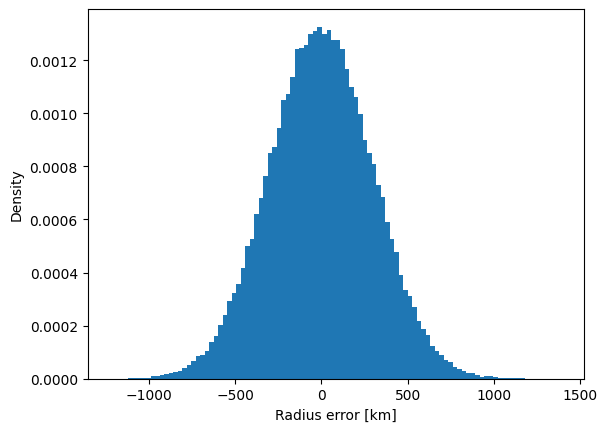

In [4]:
import matplotlib.pyplot as plt
plt.hist(r_err / 1e3, bins=100, density=True)
plt.xlabel("Radius error [km]")
plt.ylabel("Density")
plt.show()

In [5]:
from scipy.stats import kurtosis, skew
print(f"Skewness: {skew(r_err):.4f}")
print(f"Kurtosis: {kurtosis(r_err, fisher=False):.4f}")

Skewness: 0.0102
Kurtosis: 3.0048


Text(0, 0.5, 'Mean radius error [km]')

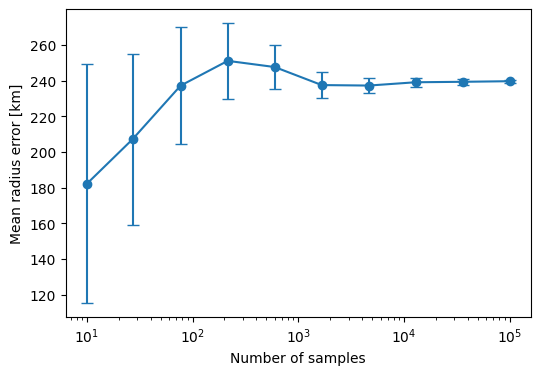

In [6]:

n_conv = np.logspace(1, np.log10(n_samples), num=10, dtype=int)
r_err_mean = np.zeros_like(n_conv, dtype=float)
r_err_std = np.zeros_like(n_conv, dtype=float)
for (i, n) in enumerate(n_conv):
    r_err_mean[i] = np.mean(np.abs(r_err[:n]))
    r_err_std[i] = np.std(r_err[:n]) / np.sqrt(n)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(n_conv, r_err_mean / 1e3, yerr=r_err_std / 1e3, fmt="o-", capsize=4)
ax.set_xscale("log")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Mean radius error [km]")

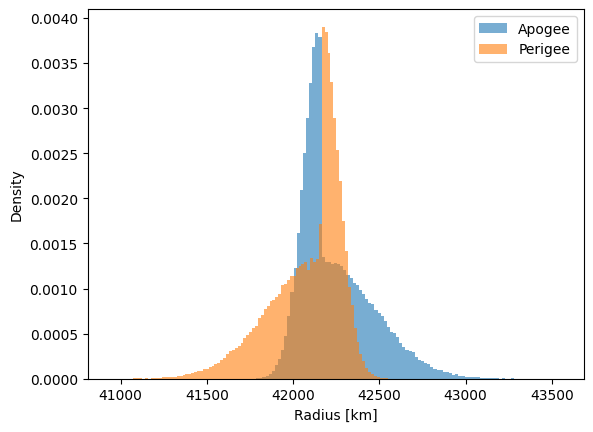

In [7]:
import matplotlib.pyplot as plt
plt.hist(r_a_samples / 1e3, bins=100, density=True, alpha=0.6, label="Apogee")
plt.hist(r_p_samples / 1e3, bins=100, density=True, alpha=0.6, label="Perigee")
plt.legend()
plt.xlabel("Radius [km]")
plt.ylabel("Density")
plt.show()

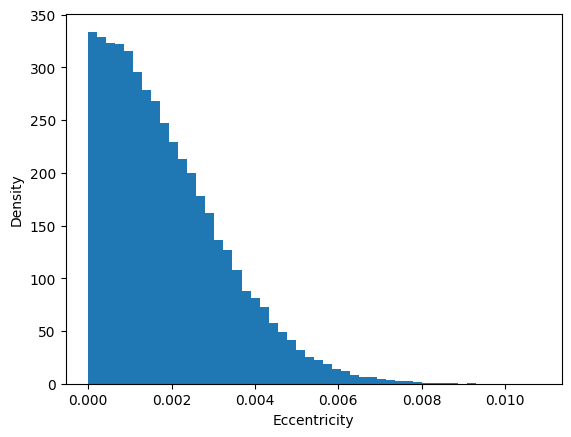

In [8]:
import matplotlib.pyplot as plt
plt.hist(e_samples, bins=50, density=True)
plt.xlabel("Eccentricity")
plt.ylabel("Density")
plt.show()

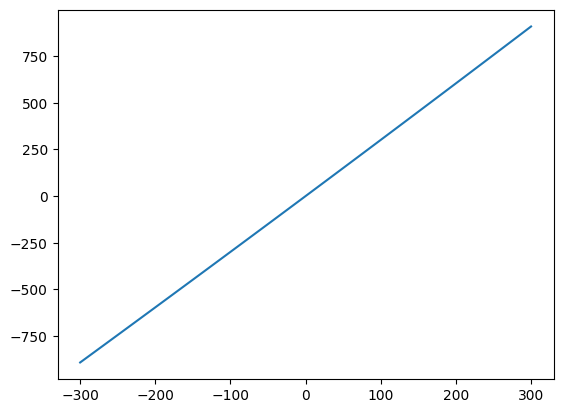

In [9]:
dr_a_sweep = np.linspace(-3 * sigma_dr_a, 3 * sigma_dr_a, 100)
r_err_sweep = np.zeros_like(dr_a_sweep, dtype=float)

for i in range(len(dr_a_sweep)):
    dr_a = dr_a_sweep[i]
    dnu = 0
    dv_mag = 0
    dv_dir = 0

    e, r_a, r_p = propagate_burn(dr_a, dnu, dv_mag, dv_dir)
    r_a_err = r_a - r_a0
    r_p_err = r_p - r_a0
    max_is_apogee = abs(r_a_err) > abs(r_p_err)
    r_err_sweep[i] = r_a_err if max_is_apogee else r_p_err


plt.plot(dr_a_sweep / 1e3, r_err_sweep / 1e3)

In [10]:
from archimedes.quadrature import gauss_hermite

# Polynomial chaos expansion
p = 3  # Polynomial order

quad_rule = gauss_hermite(p, kind="prob")
quad_rule.scaled_points(0, sigma_dr_a**2)

array([-1.73205081e+10,  0.00000000e+00,  1.73205081e+10])

In [11]:
quad_rule.scaled_weights(0, sigma_dr_a**2, density=True)

array([0.16666667, 0.66666667, 0.16666667])

In this case you could just as well do the polynomial chaos expansion in plain NumPy/SciPy or a specialized toolkit like [chaospy](https://chaospy.readthedocs.io/en/master/), since it's a non-intrusive algorithm that just requires sampling the black-box `arc.compile`d propagator function, and the PCE coefficients themselves give you the Sobol indices directly.
However, combining this with Archimedes' autodiff capabilities opens the door to interesting uncertainty-aware algorithms.
For instance, you could use PCE to estimate the mean and variance of some quantity of interest and then use this to optimize over deterministic design variables.